# **Bioinformatics Project - Computational Drug Discovery [Part 6] Comparing classifiers**

Chanin Nantasenamat

['Data Professor' YouTube channel](http://youtube.com/dataprofessor)

In this Jupyter notebook, we will be building a real-life data science project that you can include in your data science portfolio. Particularly, we will be building a machine learning model using the ChEMBL bioactivity data.

In Part 6, we will be comparing several ML algorithms for build classification models of TRPV1 inhibitors.



## **1. Import libraries**

In [45]:
! pip install lazypredict

Defaulting to user installation because normal site-packages is not writeable
  Using cached scikit_learn-0.23.1-cp36-cp36m-manylinux1_x86_64.whl (6.8 MB)
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
imbalanced-learn 0.8.1 requires scikit-learn>=0.24, but you have scikit-learn 0.23.1 which is incompatible.


In [2]:
import pandas as pd
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn import datasets
from lazypredict.Supervised import LazyClassifier, LazyRegressor

ModuleNotFoundError: No module named 'lazypredict'

## **2. Load the data set**


In [3]:
#Leo el set de datos
df = pd.read_csv('trpv1_06_bioactivity_data_3class_pIC50_pubchem_fp.csv')

In [3]:
df

,PubchemFP0,PubchemFP1,PubchemFP2,PubchemFP3,PubchemFP4,PubchemFP5,PubchemFP6,PubchemFP7,PubchemFP8,PubchemFP9,...,PubchemFP873,PubchemFP874,PubchemFP875,PubchemFP876,PubchemFP877,PubchemFP878,PubchemFP879,PubchemFP880,pIC50,standard_value
0,1,1,0,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,8.22,6.00
1,1,1,0,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,7.89,13.00
2,1,1,0,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,8.00,10.00
3,1,1,0,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,8.22,6.00
4,1,1,0,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,7.49,32.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2570,1,1,1,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,4.28,53000.00
2571,1,1,1,1,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,4.30,49700.00
2572,1,1,1,1,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,4.16,68500.00
2573,1,1,1,1,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,6.10,800.00


In [4]:
import pandas as pd
import numpy as np

In [5]:
#defino las clases
conditions = [
    (df['standard_value'] <= 10000),
    (df['standard_value'] > 10000 ) & (df['standard_value'] < 50000 ),
    (df['standard_value'] >= 50000),
    ]


In [6]:
values = ['active', 'intermediate','inactive']
df['class'] = np.select(conditions, values)
df

#Elimino la clase intermedia
df = df[df['class'] != 'intermediate']

In [7]:
import seaborn as sns
sns.set(style='ticks')
import matplotlib.pyplot as plt

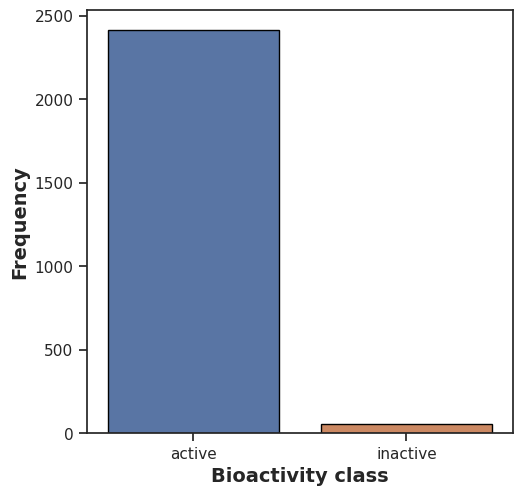

In [8]:
plt.figure(figsize=(5.5, 5.5))

sns.countplot(x='class', data=df, edgecolor='black')

plt.xlabel('Bioactivity class', fontsize=14, fontweight='bold')
plt.ylabel('Frequency', fontsize=14, fontweight='bold')

plt.savefig('plot_3_class.pdf')

In [16]:
!pip install imblearn

Defaulting to user installation because normal site-packages is not writeable
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 199.3/199.3 kB 90.6 kB/s eta 0:00:000:00:010:00:01:01
  Using cached scikit_learn-1.1.1-cp310-cp310-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (30.4 MB)
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
lazypredict 0.2.9 requires click==7.1.2, but you have click 8.0.3 which is incompatible.
lazypredict 0.2.9 requires joblib==1.0.0, but you have joblib 1.1.0 which is incompatible.
lazypredict 0.2.9 requires lightgbm==2.3.1, but you have lightgbm 3.3.2 which is incompatible.
lazypredict 0.2.9 requires numpy==1.19.1, but you have numpy 1.23.1 which is incompatible.
lazypredict 0.2.9 requires pandas==1.0.5, but you have pandas 1.4.3 which is incompatible.
lazypredict 0.2.9 requires PyYAML==5.3.1, but you have pyyaml 5.4.1 which is incompatible

# Oversampling

In [9]:
from imblearn.over_sampling import SMOTE

In [10]:
oversample = SMOTE(sampling_strategy=0.6)

In [11]:
#defino la matriz x y las clases en Y

X = df.drop('pIC50', axis=1)
X = X.drop('class', axis=1)
X = X.drop('standard_value', axis=1)
Y = df['class']

In [12]:
#Realizo el sobremuestreo
X, Y = oversample.fit_resample(X, Y)

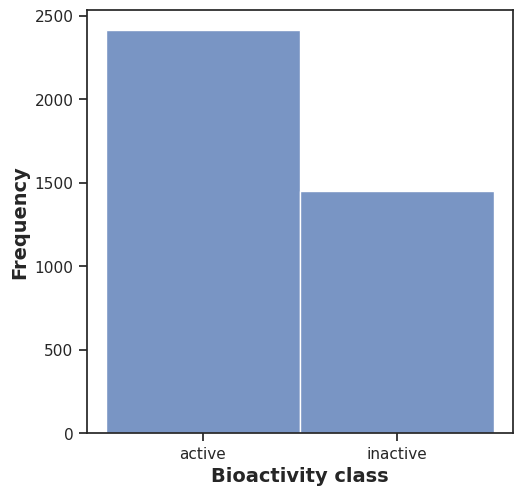

In [13]:
#Hago un gráfico
plt.figure(figsize=(5.5, 5.5))

sns.histplot(data=Y)

plt.xlabel('Bioactivity class', fontsize=14, fontweight='bold')
plt.ylabel('Frequency', fontsize=14, fontweight='bold')

plt.savefig('plot_3_class_oversampling.pdf')

In [20]:
np.count_nonzero(Y == 'inactive')

1449

In [24]:
df

,PubchemFP0,PubchemFP1,PubchemFP2,PubchemFP3,PubchemFP4,PubchemFP5,PubchemFP6,PubchemFP7,PubchemFP8,PubchemFP9,...,PubchemFP874,PubchemFP875,PubchemFP876,PubchemFP877,PubchemFP878,PubchemFP879,PubchemFP880,pIC50,standard_value,class
0,1,1,0,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,8.22,6.00,active
1,1,1,0,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,7.89,13.00,active
2,1,1,0,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,8.00,10.00,active
3,1,1,0,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,8.22,6.00,active
4,1,1,0,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,7.49,32.00,active
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2569,1,1,1,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,4.09,81600.00,inactive
2570,1,1,1,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,4.28,53000.00,inactive
2572,1,1,1,1,0,0,0,0,0,1,...,0,0,0,0,0,0,0,4.16,68500.00,inactive
2573,1,1,1,1,0,0,0,0,0,1,...,0,0,0,0,0,0,0,6.10,800.00,active


## **3. Data pre-processing**

In [14]:
# Examine X dimension
X.shape

(3864, 881)

In [40]:
#Eliminé la selección de atributos
# Remove low variance features
from sklearn.feature_selection import VarianceThreshold
selection = VarianceThreshold(threshold=(.8 * (1 - .8)))    
X = selection.fit_transform(X)
X.shape

(3864, 157)

## **4. Compare ML algorithms**

In [14]:
    X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

In [16]:
# fit all models
clf = LazyClassifier(verbose=0,ignore_warnings=True, predictions=True, custom_metric=None)
models, predictions = clf.fit(X_train, X_test, Y_train, Y_test)

SyntaxError: invalid syntax (<ipython-input-16-62070d0d7ca0>, line 2)

,PubchemFP0,PubchemFP1,PubchemFP2,PubchemFP3,PubchemFP4,PubchemFP5,PubchemFP6,PubchemFP7,PubchemFP8,PubchemFP9,...,PubchemFP873,PubchemFP874,PubchemFP875,PubchemFP876,PubchemFP877,PubchemFP878,PubchemFP879,PubchemFP880,pIC50,standard_value
0,1,1,0,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0


# Divido el set de datos en 10

In [46]:
from numpy import savetxt

In [55]:
#Divido el set de datos en 100 realizo la construcción de los modelos 
from numpy import savetxt
import numpy
lenX = range(len(X))
aa = numpy.array_split(numpy.array(lenX),100)


externo = 1

import math


def common_data(list1, list2):
    result = False
  
    # traverse in the 1st list
    for x in list1:
  
        # traverse in the 2nd list
        for y in list2:
    
            # if one common
            if x == y:
                result = True
                return result 
                  
    return result

    #primero calculo TP, TN, FP, FN para cada modelo
    
    # Creo una matriz con las dimensiones el número de modelos X 4 para las métricas TP[0], TN[1], FP[2], FN[3]
    
    
    #rows, cols = ( len(predictions.columns.values) , 4)
    rows, cols = ( N, 4)
    
    arr = np.zeros((rows, cols))
    

count = 0
N = 10

modelsAv = ['LinearSVC','SGDClassifier','MLPClassifier','Perceptron','LogisticRegression','LogisticRegressionCV','SVC','CalibratedClassifierCV','PassiveAggressiveClassifier','LabelPropagation','LabelSpreading','RandomForestClassifier','GradientBoostingClassifier','QuadraticDiscriminantAnalysis','HistGradientBoostingClassifier','RidgeClassifierCV','RidgeClassifier','AdaBoostClassifier','ExtraTreesClassifier','KNeighborsClassifier','BaggingClassifier','BernoulliNB','LinearDiscriminantAnalysis','GaussianNB','NuSVC','DecisionTreeClassifier','NearestCentroid','ExtraTreeClassifier','CheckingClassifier','DummyClassifier']


listaPred = list()

resModelos = {}
#Para N modelos calculo los estadísticos promedios
estadisticos = 1
while (count < N):   
    print(count)
    # Tengo que dejar afuera a aa[count]
    yy = []
        
    for i in range(len(aa)):
        if i != count:
            for e in range(len(aa[i])):
                yy.append(aa[i][e])
    
    YY = Y.iloc[yy]
    XX = X[yy]
    

    
    ## Para el cálculo de los modelos

    # Perform data splitting using 80/20 ratio
    X_train, X_test, Y_train, Y_test = train_test_split(XX, YY, test_size=0.2, random_state=42)
    
    if externo != 1:
        print("interno")
        clf = LazyClassifier(verbose=0,ignore_warnings=True, custom_metric=None, predictions=True)
        models,predictions= clf.fit(X_train, X_test, Y_train, Y_test)
    
    
    ##Para el cálculo con el set externo
    if externo == 1:
        print("externo")
        clf = LazyClassifier(verbose=0,ignore_warnings=True, custom_metric=None, predictions=True)
        models,predictions= clf.fit(X_train, Xext, Y_train, Yext)
    
   
    listaPred.append(predictions)
    
     #Calculo los estadísticos
    
    #primero calculo TP, TN, FP, FN para cada modelo

    # Creo una matriz con las dimensiones el número de modelos X 4 para las métricas TP[0], TN[1], FP[2], FN[3]


    rows, cols = ( len(modelsAv) , 4)
    arr = np.zeros((rows, cols))
    

    print(predictions.columns.values)
    
    clasePositiva = 'active'
    
    for m in range(len(predictions.columns.values)):
        for row in predictions.index.values:
            
            #print(row, ' ', m ,' ', Y[row], ' ', predictions.iloc[row,m])
            
            if externo != 1:
                #TP
                if clasePositiva == Y_test.iloc[row] and predictions.iloc[row,m] == clasePositiva:
                    arr[m,0] = arr[m,0] + 1
                #TN    
                if clasePositiva != Y_test.iloc[row] and predictions.iloc[row,m] != clasePositiva:
                    arr[m, 1] = arr[m,1] + 1
                #FP
                if clasePositiva != Y_test.iloc[row] and predictions.iloc[row,m] == clasePositiva:
                    arr[m,2] = arr[m,2] + 1
                #FN
                if clasePositiva == Y_test.iloc[row] and predictions.iloc[row,m] != clasePositiva:
                    arr[m,3] = arr[m,3] + 1

            
            if externo == 1:
                #TP
                if clasePositiva == Yext.iloc[row] and predictions.iloc[row,m] == clasePositiva:
                    arr[m,0] = arr[m,0] + 1
                #TN    
                if clasePositiva != Yext.iloc[row] and predictions.iloc[row,m] != clasePositiva:
                    arr[m, 1] = arr[m,1] + 1
                #FP
                if clasePositiva != Yext.iloc[row] and predictions.iloc[row,m] == clasePositiva:
                    arr[m,2] = arr[m,2] + 1
                #FN
                if clasePositiva == Yext.iloc[row] and predictions.iloc[row,m] != clasePositiva:
                    arr[m,3] = arr[m,3] + 1
    
    #np.insert(arr, 3, predictions.columns.values, axis=1) 
    tasas = pd.DataFrame(arr, columns = ['TP','TN','FP','FN'])
    tasas['modelo'] = modelsAv
    tasas.to_csv('tasas/tasas_'+str(count)+'.csv')
    
    predictions.to_csv('predicciones/pred_'+str(count)+'.csv')
    
    #Calculo por modelo 
   
    if count == 0:
        estadisticos = pd.DataFrame(columns=['accuracy', 'specificity', 'sensibility','precision','recall','MCC'], index=modelsAv)
    
    indice = 0
    for m in predictions.columns.values:
        
        spe = arr[indice, 1] / (arr[indice, 1] + arr[indice, 2])
        sen = arr[indice, 0] / (arr[indice, 0] + arr[indice, 3])
        acc = (arr[indice, 0] + arr[indice, 1]) / (arr[indice, 0] + arr[indice, 1]+ arr[indice, 2] + arr[indice, 3])
        pre = arr[indice, 0] / (arr[indice, 0] + arr[indice, 2])
        recall = arr[indice, 0] / (arr[indice, 0] + arr[indice, 3])
        valor = (arr[indice, 0]+arr[indice, 2])*(arr[indice, 0]+arr[indice, 3])*(arr[indice, 1]+arr[indice, 2])*(arr[indice, 1]+arr[indice, 3])
        mcc = (( (arr[indice, 0] * arr[indice, 1]) - (arr[indice, 2] * arr[indice, 3])) / math.sqrt(valor) ) if valor != 0 else 0
        
        if m in estadisticos.index.values:
        
            if  math.isnan(estadisticos.loc[m,'specificity']):

                estadisticos.loc[m,'specificity'] = spe
                estadisticos.loc[m,'sensibility'] = sen
                estadisticos.loc[m,'accuracy'] = acc
                estadisticos.loc[m,'precision'] = pre
                estadisticos.loc[m,'recall'] = recall
                estadisticos.loc[m,'MCC'] = mcc
            else:

                estadisticos.loc[m,'specificity'] = estadisticos.loc[m,'specificity'] + spe
                estadisticos.loc[m,'sensibility'] = estadisticos.loc[m,'sensibility'] + sen
                estadisticos.loc[m,'accuracy'] = estadisticos.loc[m,'accuracy'] + acc
                estadisticos.loc[m,'precision'] = estadisticos.loc[m,'precision'] + pre
                estadisticos.loc[m,'recall'] = estadisticos.loc[m,'recall'] + recall
                estadisticos.loc[m,'MCC'] = estadisticos.loc[m,'MCC'] + mcc
            
            
        indice = indice + 1
        
        
   
        
    
    #recorro todos los modelos generados y sumo el valor del accuracy en este caso
    ind = 0
    for m in models.index.values:
        if m in resModelos.keys():
                       
                              
            resModelos[m] = resModelos[m] + models.iat[ind,0]
            
            
        else:
            
            resModelos[m] =  models.iat[ind,0]
        ind = ind + 1
    
    count = count + 1
for key in resModelos.keys():
    resModelos[key] = resModelos[key] / N
    

 #Divido todos los valores del dataframe por N   
estadisticos = estadisticos / N

  0%|                                                                                         | 0/30 [00:00<?, ?it/s]

0
externo


100%|████████████████████████████████████████████████████████████████████████████████| 30/30 [00:09<00:00,  3.15it/s]


['AdaBoostClassifier' 'BaggingClassifier' 'BernoulliNB'
 'CalibratedClassifierCV' 'DecisionTreeClassifier' 'DummyClassifier'
 'ExtraTreeClassifier' 'ExtraTreesClassifier' 'GaussianNB'
 'KNeighborsClassifier' 'LabelPropagation' 'LabelSpreading'
 'LinearDiscriminantAnalysis' 'LinearSVC' 'NearestCentroid' 'NuSVC'
 'PassiveAggressiveClassifier' 'Perceptron'
 'QuadraticDiscriminantAnalysis' 'RandomForestClassifier'
 'RidgeClassifier' 'RidgeClassifierCV' 'SGDClassifier' 'SVC'
 'XGBClassifier' 'LGBMClassifier']


  0%|                                                                                         | 0/30 [00:00<?, ?it/s]

...

['AdaBoostClassifier' 'BaggingClassifier' 'BernoulliNB'
 'CalibratedClassifierCV' 'DecisionTreeClassifier' 'DummyClassifier'
 'ExtraTreeClassifier' 'ExtraTreesClassifier' 'GaussianNB'
 'KNeighborsClassifier' 'LabelPropagation' 'LabelSpreading'
 'LinearDiscriminantAnalysis' 'LinearSVC' 'NearestCentroid' 'NuSVC'
 'PassiveAggressiveClassifier' 'Perceptron'
 'QuadraticDiscriminantAnalysis' 'RandomForestClassifier'
 'RidgeClassifier' 'RidgeClassifierCV' 'SGDClassifier' 'SVC'
 'XGBClassifier' 'LGBMClassifier']


  0%|                                                                                         | 0/30 [00:00<?, ?it/s]

99
externo


100%|████████████████████████████████████████████████████████████████████████████████| 30/30 [00:08<00:00,  3.35it/s]


['AdaBoostClassifier' 'BaggingClassifier' 'BernoulliNB'
 'CalibratedClassifierCV' 'DecisionTreeClassifier' 'DummyClassifier'
 'ExtraTreeClassifier' 'ExtraTreesClassifier' 'GaussianNB'
 'KNeighborsClassifier' 'LabelPropagation' 'LabelSpreading'
 'LinearDiscriminantAnalysis' 'LinearSVC' 'NearestCentroid' 'NuSVC'
 'PassiveAggressiveClassifier' 'Perceptron'
 'QuadraticDiscriminantAnalysis' 'RandomForestClassifier'
 'RidgeClassifier' 'RidgeClassifierCV' 'SGDClassifier' 'SVC'
 'XGBClassifier' 'LGBMClassifier']


In [29]:
for key in resModelos.keys():
    print(key,'\t\t\t',resModelos[key])

DecisionTreeClassifier 			 0.9927899686520386
XGBClassifier 			 0.995788923719957
BaggingClassifier 			 0.9934378265412752
SGDClassifier 			 0.989090909090909
LinearSVC 			 0.990856844305121
Perceptron 			 0.9871055381400204
LogisticRegression 			 0.9915778474399172
LGBMClassifier 			 0.994702194357366
CalibratedClassifierCV 			 0.9918599791013597
RandomForestClassifier 			 0.9942528735632175
ExtraTreesClassifier 			 0.9946708463949833
SVC 			 0.9910658307210041
LabelPropagation 			 0.993657262277952
LabelSpreading 			 0.993657262277952
KNeighborsClassifier 			 0.9896551724137934
ExtraTreeClassifier 			 0.9920167189132708
LinearDiscriminantAnalysis 			 0.988735632183907
RidgeClassifierCV 			 0.9874817136886093
RidgeClassifier 			 0.9884117032392886
PassiveAggressiveClassifier 			 0.9898223615464993
AdaBoostClassifier 			 0.9883176593521417
QuadraticDiscriminantAnalysis 			 0.9809299895506792
GaussianNB 			 0.9226123301985366
BernoulliNB 			 0.9217868338557992
NuSVC 			 0.92067920585161

In [54]:
nRow = dfE.shape[0] if externo== 1 else len(listaPred[corrida])

for ejemplo in range(nRow):
    
    dfPred = pd.DataFrame(columns = ['modelo','active','inactive'])
    
    for m in modelsAv:
        
        for corrida in range(len(listaPred)):
            if m in listaPred[corrida].loc[ejemplo].index.values:
                predicho = listaPred[corrida].loc[ejemplo, m]
                #verifico si existe el modelo en el dfPred

                if m in dfPred.modelo.values:
                    if predicho == 'active':
                        dfPred.loc[dfPred['modelo'] == m,'active'] +=  1
                    if predicho == 'inactive':
                        dfPred.loc[dfPred['modelo'] == m,'inactive'] += 1

                else:
                    data = []
                    if predicho == 'active':
                        data = [[m,1,0]]
                    if predicho == 'inactive':
                        data = [[m,0,1]]

                    dfAux = pd.DataFrame(data,columns = ['modelo','active','inactive'])
                    dfPred = dfPred.append(dfAux)    
    dfPred['active'] /= N
    dfPred['inactive'] /= N
    dfPred.to_csv('predicciones/cuenta/final_'+str(ejemplo)+'.csv')        
        

KeyError: 765

In [56]:
estadisticos.to_csv('estadisticos.csv')

[(0.0, 1.0)]

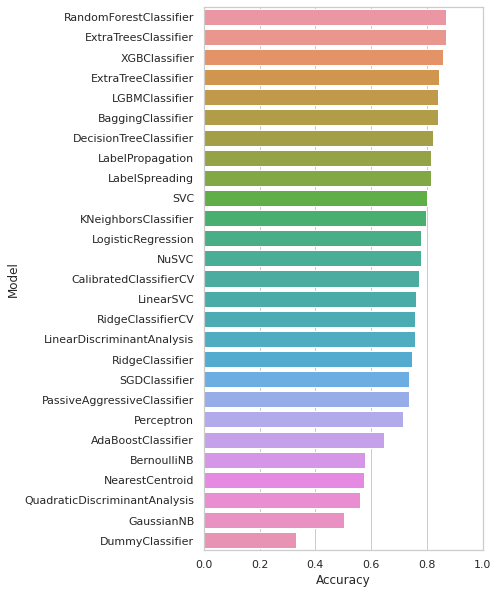

In [42]:
# Bar plot of R-squared values
import matplotlib.pyplot as plt
import seaborn as sns

#train["R-Squared"] = [0 if i < 0 else i for i in train.iloc[:,0] ]

plt.figure(figsize=(5, 10))
sns.set_theme(style="whitegrid")
ax = sns.barplot(y=predictions.index, x="Accuracy", data=predictions)
ax.set(xlim=(0, 1))